# Create Jobs from Survey Responses #

This sample creates a job in ArcGIS Workflow Manager for each response to a Survey 123 survey. It will query the survey data, and use that information to create a new job with a priority based on data in the survey, copy any attachments from the survey to the job, and link the job to the survey via extended properties

### Create Connections to Enterprise and Online ###

In [3]:
import arcgis
import tempfile
from arcgis.gis.workflowmanager import WorkflowManager

<Item title:"Damaged Infrastructure" type:Form owner:bk_01>
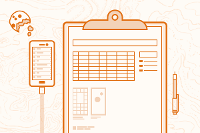

In [4]:
online = arcgis.gis.GIS(profile='agol')
survey = online.content.search('title:"Damaged Infrastructure" type:"Form"')[0]
survey

### Find the survey data ###

In [5]:
survey_data = survey.related_items('Survey2Service')[0]
survey_layer = survey_data.layers[0]
survey_features = survey_layer.query()
survey_features.sdf

,objectid,globalid,CreationDate,Creator,EditDate,Editor,type_of_item,SHAPE
0,6,d0b9da18-c6eb-4e3a-8ac1-db39dfaaf127,2020-07-27 21:38:20.219000101,adelgadillo_solutions,2020-07-27 21:38:20.219000101,adelgadillo_solutions,sign,"{""x"": -117.19751319999804, ""y"": 34.05609419999..."
1,7,142e0ac6-d74b-4685-84c3-16afbb40c3f1,2020-07-27 21:40:06.358000040,adelgadillo_solutions,2020-07-27 21:40:06.358000040,adelgadillo_solutions,tree,"{""x"": -117.20251749527404, ""y"": 34.05563510623..."
2,8,284ce6a4-1e26-4628-8d41-5a766d570afc,2020-07-27 21:40:30.857000113,adelgadillo_solutions,2020-07-27 21:40:30.857000113,adelgadillo_solutions,streetlight,"{""x"": -117.2007358661602, ""y"": 34.055539896910..."


### Connect to the Workflow Manager Server ###

In [6]:
gis = arcgis.gis.GIS(profile='ps0008227', verify_cert=False)
item = gis.content.search('title:"Python Sample"')[0]
workflowManager = WorkflowManager(item)

### Make sure the job template has an extended property field ###

In [9]:
job_template_ids = [x.job_template_id for x in workflowManager.job_templates if x.job_template_name == 'Fix Damaged infrastructure']
job_template_id = job_template_ids[0]
job_template = workflowManager.job_template(job_template_id)
job_template.extended_property_table_definitions

WrkdpVMVTdWNSeSgE2w1rw


[{'tableName': 'request_info',
  'tableAlias': 'Request_info',
  'tableOrder': 0,
  'relationshipType': 'OneToOne',
  'extendedPropertyDefinitions': [{'propertyName': 'survey_id',
    'propertyAlias': 'Survey ID',
    'propertyOrder': 0,
    'dataType': 'String',
    'defaultValue': '',
    'fieldLength': 50,
    'required': True,
    'editable': True,
    'visible': True}]}]

### Create a job for each survey ###

In [10]:
def get_priority_from_type(type_of_item):
    if (type_of_item == 'sign'):
        return 'High'
    elif (type_of_item == 'sidewalk'):
        return 'Low'
    else:
        return 'Medium'
    
    
def copy_attachments(oid, attachments, job_id):
    with tempfile.TemporaryDirectory() as temp_dir:
        for attachment in attachments:
            files = survey_layer.attachments.download(oid, attachment['id'], save_path=temp_dir)
            workflowManager.jobs.get(job_id).add_attachment(files[0])
            

for f in survey_features.features:
    priority = get_priority_from_type(f.get_value('type_of_item'))
    
    # Check for existing jobs with the ext property field
    survey_id = f.get_value('globalid')
    num = workflowManager.jobs.search(query=f"request_info.survey_id = '{survey_id}'", fields=['job_id'], num=1)['num']
    if num > 0:
        continue    
    
    new_jobs = workflowManager.jobs.create(job_template_id, priority=priority)
    if new_jobs != None and len(new_jobs) == 1:
        job_id = new_jobs[0]
        print(f'Created job {job_id}')
    else:
        print(f'Failed to create job: {new_jobs}')
        continue

    # Copy the attachments if there are any
    survey_oid = f.get_value('objectid')
    attachments = survey_layer.attachments.get_list(survey_oid)
    if (attachments):
        print('Survey has attachments, copying them to job')
        copy_attachments(survey_oid, attachments, job_id)
    
    # Set the extended property value
    workflowManager.jobs.update(job_id, {
        'extendedProperties': [{'identifier': 'request_info.survey_id', 'value': survey_id}]
    })
    

Created job tNyssd9IQ7C9wA9FwlqWjg
Survey has attachments, copying them to job
Created job dQ6OaHvfScmk_91Q1R2tZw
Survey has attachments, copying them to job
Created job P9E-LlLHT2CQbwQKACxSGw
Survey has attachments, copying them to job


In [11]:
# Search for all the jobs related to surveys
workflowManager.jobs.search(query=f"request_info.survey_id is not null and request_info.survey_id <> ''", fields=['job_id', 'request_info.survey_id'])

{'q': "exmhczkswtzig_survey_id is not null and exmhczkswtzig_survey_id <> ''",
 'fields': [{'name': 'job_id', 'fieldType': 'String'},
  {'name': 'request_info.survey_id', 'fieldType': 'String'}],
 'results': [['tNyssd9IQ7C9wA9FwlqWjg',
   'd0b9da18-c6eb-4e3a-8ac1-db39dfaaf127'],
  ['dQ6OaHvfScmk_91Q1R2tZw', '142e0ac6-d74b-4685-84c3-16afbb40c3f1'],
  ['P9E-LlLHT2CQbwQKACxSGw', '284ce6a4-1e26-4628-8d41-5a766d570afc']],
 'start': 0,
 'next_start': -1,
 'num': 3}